In [50]:
import kagglehub
emmarex_plantdisease_path = kagglehub.dataset_download('emmarex/plantdisease')

print('Data source import complete.')

Data source import complete.


In [51]:
emmarex_plantdisease_path

'/kaggle/input/plantdisease'

In [52]:
import torch
import torch.nn as nn
import torch.optim as optim
from torchvision import datasets, models, transforms
from torch.utils.data import DataLoader, random_split
import matplotlib.pyplot as plt
import torchvision
import numpy as np
from sklearn.metrics import classification_report, confusion_matrix
import seaborn as sns


In [53]:
import os
# Paths (adjust if needed)
ORIG_DATASET = "/kaggle/input/plantdisease/PlantVillage"  # original dataset with 15 class subfolders
SPLIT_BASE = "/kaggle/working/split_dataset"
TRAIN_DIR = os.path.join(SPLIT_BASE, "train")
TEST_DIR  = os.path.join(SPLIT_BASE, "test")

# Where to save best weights
BEST_WEIGHTS_PATH = "/kaggle/working/best_model.weights.h5"

print("Configured paths:")
print("ORIG_DATASET:", ORIG_DATASET)
print("TRAIN_DIR:", TRAIN_DIR)
print("TEST_DIR:", TEST_DIR)
print("BEST_WEIGHTS_PATH:", BEST_WEIGHTS_PATH)

Configured paths:
ORIG_DATASET: /kaggle/input/plantdisease/PlantVillage
TRAIN_DIR: /kaggle/working/split_dataset/train
TEST_DIR: /kaggle/working/split_dataset/test
BEST_WEIGHTS_PATH: /kaggle/working/best_model.weights.h5


In [54]:
transform = transforms.Compose([
    transforms.Resize((227, 227)),
    transforms.RandomHorizontalFlip(),
    transforms.RandomRotation(10),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.5, 0.5, 0.5], std=[0.5, 0.5, 0.5])
])

# Load the entire dataset
dataset = datasets.ImageFolder(root=ORIG_DATASET, transform=transform)

In [55]:
len(dataset)

20638

In [56]:
dataset.classes

['Pepper__bell___Bacterial_spot',
 'Pepper__bell___healthy',
 'Potato___Early_blight',
 'Potato___Late_blight',
 'Potato___healthy',
 'Tomato_Bacterial_spot',
 'Tomato_Early_blight',
 'Tomato_Late_blight',
 'Tomato_Leaf_Mold',
 'Tomato_Septoria_leaf_spot',
 'Tomato_Spider_mites_Two_spotted_spider_mite',
 'Tomato__Target_Spot',
 'Tomato__Tomato_YellowLeaf__Curl_Virus',
 'Tomato__Tomato_mosaic_virus',
 'Tomato_healthy']

In [57]:
# First split: Train+Validation and Test
train_val_size = int(0.9 * len(dataset))   # 90% for train+val
test_size = len(dataset) - train_val_size  # 10% for test
train_val_dataset, test_dataset = random_split(dataset, [train_val_size, test_size])

# Second split: Train and Validation (from train_val_dataset)
val_size = int(0.2 * train_val_size)   # 20% of train_val for validation
train_size = train_val_size - val_size

train_dataset, val_dataset = random_split(train_val_dataset, [train_size, val_size])

print("Train size:", len(train_dataset))
print("Validation size:", len(val_dataset))
print("Test size:", len(test_dataset))


Train size: 14860
Validation size: 3714
Test size: 2064


In [58]:
# Create data loaders
train_loader = DataLoader(train_dataset, batch_size=32, shuffle=True)
validation_loader = DataLoader(val_dataset,batch_size=32,shuffle=False)
test_loader = DataLoader(test_dataset, batch_size=32, shuffle=False)

In [59]:
for i, (images, labels) in enumerate(train_loader):
    print(images.shape)
    print(labels.shape)
    break

torch.Size([32, 3, 227, 227])
torch.Size([32])


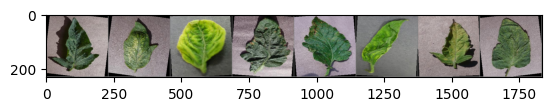

In [60]:
def imshow(img):
    img = img / 2 + 0.5     # unnormalize
    npimg = img.numpy()
    plt.imshow(np.transpose(npimg, (1, 2, 0)))
    plt.show()

# show images
imshow(torchvision.utils.make_grid(images[:8]))

In [61]:
def train_model(model, optimizer, criterion, train_loader, val_loader, num_epochs=5):
    train_acc, val_acc, train_loss, val_loss = [], [], [], []
    
    for epoch in range(num_epochs):
        model.train()
        correct, total, running_loss = 0, 0, 0
        for images, labels in train_loader:
            images,labels = images.to(device),labels.to(device)
            optimizer.zero_grad()
            outputs = model(images)
            loss = criterion(outputs, labels)
            loss.backward()
            optimizer.step()

            running_loss += loss.item()
            _, preds = torch.max(outputs, 1)
            correct += (preds == labels).sum().item()
            total += labels.size(0)

        train_acc.append(correct / total)
        train_loss.append(running_loss / len(train_loader))

        # Validation
        model.eval()
        correct, total, running_loss = 0, 0, 0
        with torch.no_grad():
            for images, labels in val_loader:
                images,labels  = images.to(device),labels.to(device)
                outputs = model(images)
                loss = criterion(outputs, labels)
                running_loss += loss.item()
                _, preds = torch.max(outputs, 1)
                correct += (preds == labels).sum().item()
                total += labels.size(0)

        val_acc.append(correct / total)
        val_loss.append(running_loss / len(val_loader))

        print(f"Epoch [{epoch+1}/{num_epochs}] "
              f"Train Acc: {train_acc[-1]:.4f}, Val Acc: {val_acc[-1]:.4f}")



    plt.figure(figsize=(12,5))
    plt.subplot(1,2,1)
    plt.plot(train_acc, label="Train Acc")
    plt.plot(val_acc, label="Val Acc")
    plt.legend(); plt.title("Accuracy")
    
    plt.subplot(1,2,2)
    plt.plot(train_loss, label="Train Loss")
    plt.plot(val_loss, label="Val Loss")
    plt.legend(); plt.title("Loss")
    plt.show()

    return model

In [68]:
def test_model(model, test_loader):
    model.eval()
    all_preds, all_labels = [], []
    with torch.no_grad():
        for images, labels in test_loader:
            images,labels = images.to(device),labels.to(device)
            outputs = model(images)
            _, preds = torch.max(outputs, 1)
            all_preds.extend(preds.cpu().numpy())
            all_labels.extend(labels.cpu().numpy())

    # Classification report
    print("\nClassification Report:")
    print(classification_report(all_labels, all_preds, target_names=dataset.classes))

    # Confusion Matrix
    cm = confusion_matrix(all_labels, all_preds)
    plt.figure(figsize=(10,8))
    sns.heatmap(cm, annot=True, cmap="Blues", 
                xticklabels=dataset.classes, yticklabels=dataset.classes,fmt='d')
    plt.title("Confusion Matrix")
    plt.xlabel("Predicted")
    plt.ylabel("True")
    plt.show()


In [63]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
device

device(type='cuda')

In [64]:
from torchvision import models

# Load pre-trained ResNet50 model
model = models.resnet50(weights='DEFAULT')


Epoch [1/10] Train Acc: 0.8972, Val Acc: 0.8786
Epoch [2/10] Train Acc: 0.9608, Val Acc: 0.9715
Epoch [3/10] Train Acc: 0.9690, Val Acc: 0.9561
Epoch [4/10] Train Acc: 0.9742, Val Acc: 0.9550
Epoch [5/10] Train Acc: 0.9773, Val Acc: 0.9712
Epoch [6/10] Train Acc: 0.9826, Val Acc: 0.9782
Epoch [7/10] Train Acc: 0.9811, Val Acc: 0.9742
Epoch [8/10] Train Acc: 0.9825, Val Acc: 0.9817
Epoch [9/10] Train Acc: 0.9849, Val Acc: 0.9790
Epoch [10/10] Train Acc: 0.9835, Val Acc: 0.9758


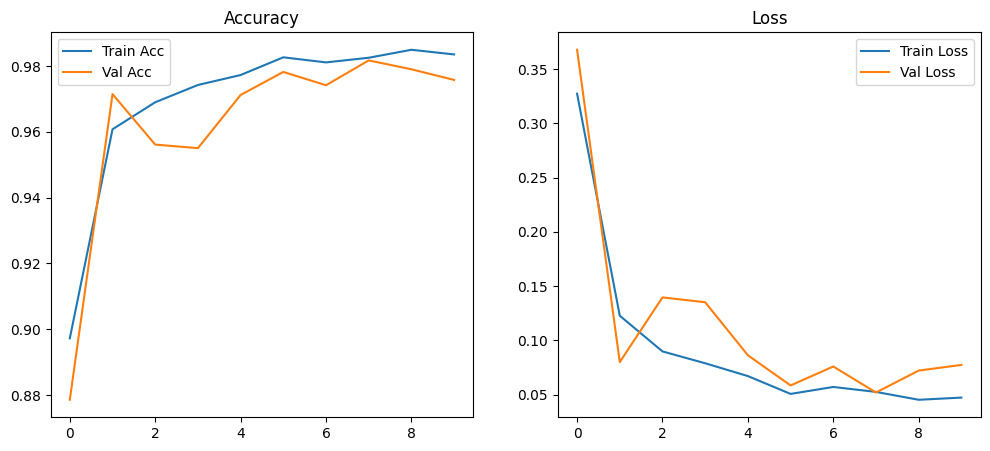


Classification Report:
                                             precision    recall  f1-score   support

              Pepper__bell___Bacterial_spot       0.98      1.00      0.99       102
                     Pepper__bell___healthy       1.00      0.99      1.00       152
                      Potato___Early_blight       1.00      0.92      0.96       103
                       Potato___Late_blight       0.95      0.99      0.97        96
                           Potato___healthy       1.00      1.00      1.00        15
                      Tomato_Bacterial_spot       1.00      1.00      1.00       194
                        Tomato_Early_blight       0.96      0.82      0.89        96
                         Tomato_Late_blight       0.99      0.97      0.98       209
                           Tomato_Leaf_Mold       0.99      0.93      0.96        94
                  Tomato_Septoria_leaf_spot       0.87      0.99      0.93       176
Tomato_Spider_mites_Two_spotted_spider_m

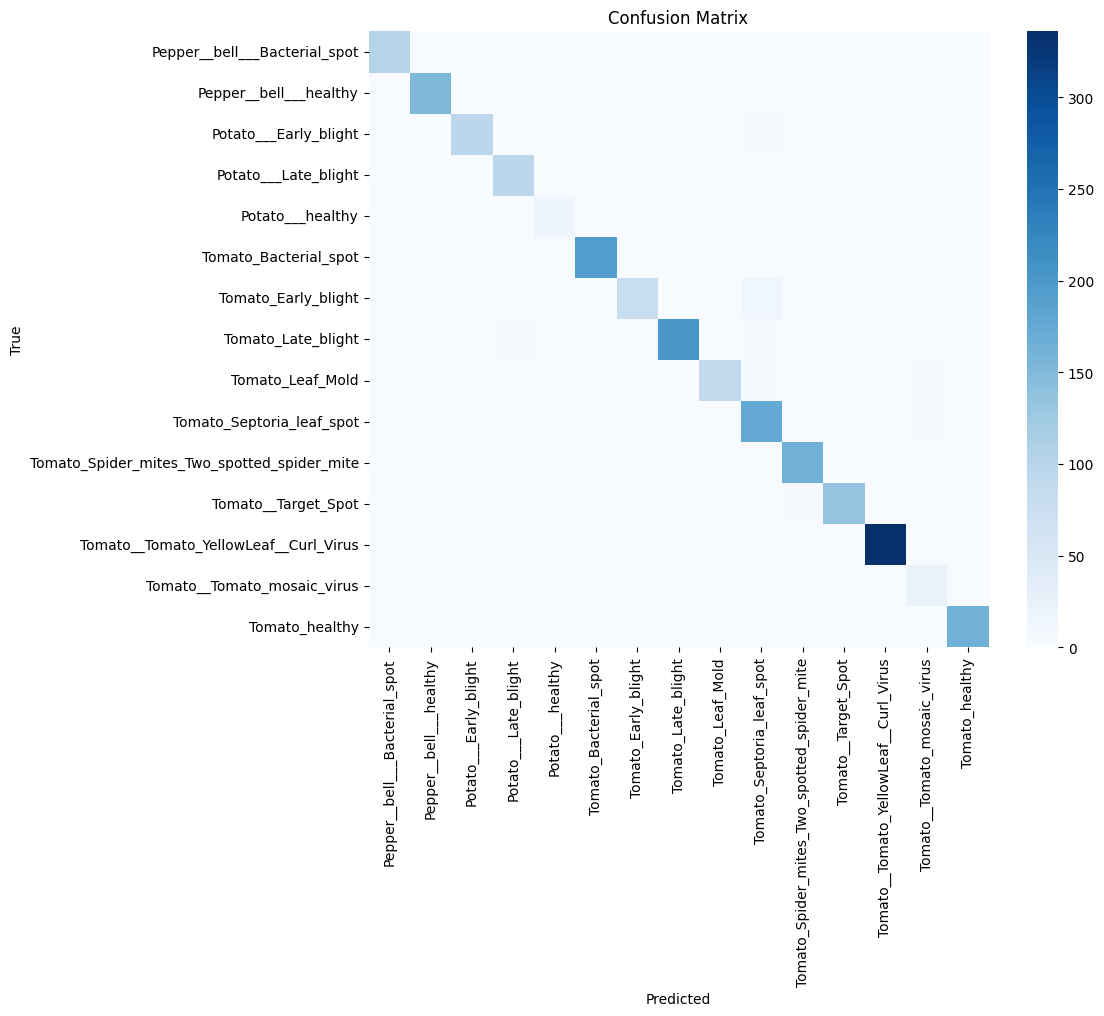

Model saved as resnet50_plant_disease.pth


In [65]:

# Replace the fully connected layer
model.fc = nn.Linear(model.fc.in_features, len(dataset.classes))

# Define loss function and optimizer
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=0.001)

model = model.to(device)

model = train_model(model, optimizer, criterion, train_loader, validation_loader, num_epochs=10)
test_model(model, test_loader)

torch.save(model.state_dict(), "resnet50_plant_disease.pth")
print("Model saved as resnet50_plant_disease.pth")


Classification Report:
                                             precision    recall  f1-score   support

              Pepper__bell___Bacterial_spot       0.97      1.00      0.99       102
                     Pepper__bell___healthy       1.00      0.99      0.99       152
                      Potato___Early_blight       1.00      0.93      0.96       103
                       Potato___Late_blight       0.99      1.00      0.99        96
                           Potato___healthy       0.94      1.00      0.97        15
                      Tomato_Bacterial_spot       1.00      0.99      0.99       194
                        Tomato_Early_blight       0.95      0.82      0.88        96
                         Tomato_Late_blight       0.99      0.98      0.99       209
                           Tomato_Leaf_Mold       1.00      0.93      0.96        94
                  Tomato_Septoria_leaf_spot       0.87      0.99      0.93       176
Tomato_Spider_mites_Two_spotted_spider_m

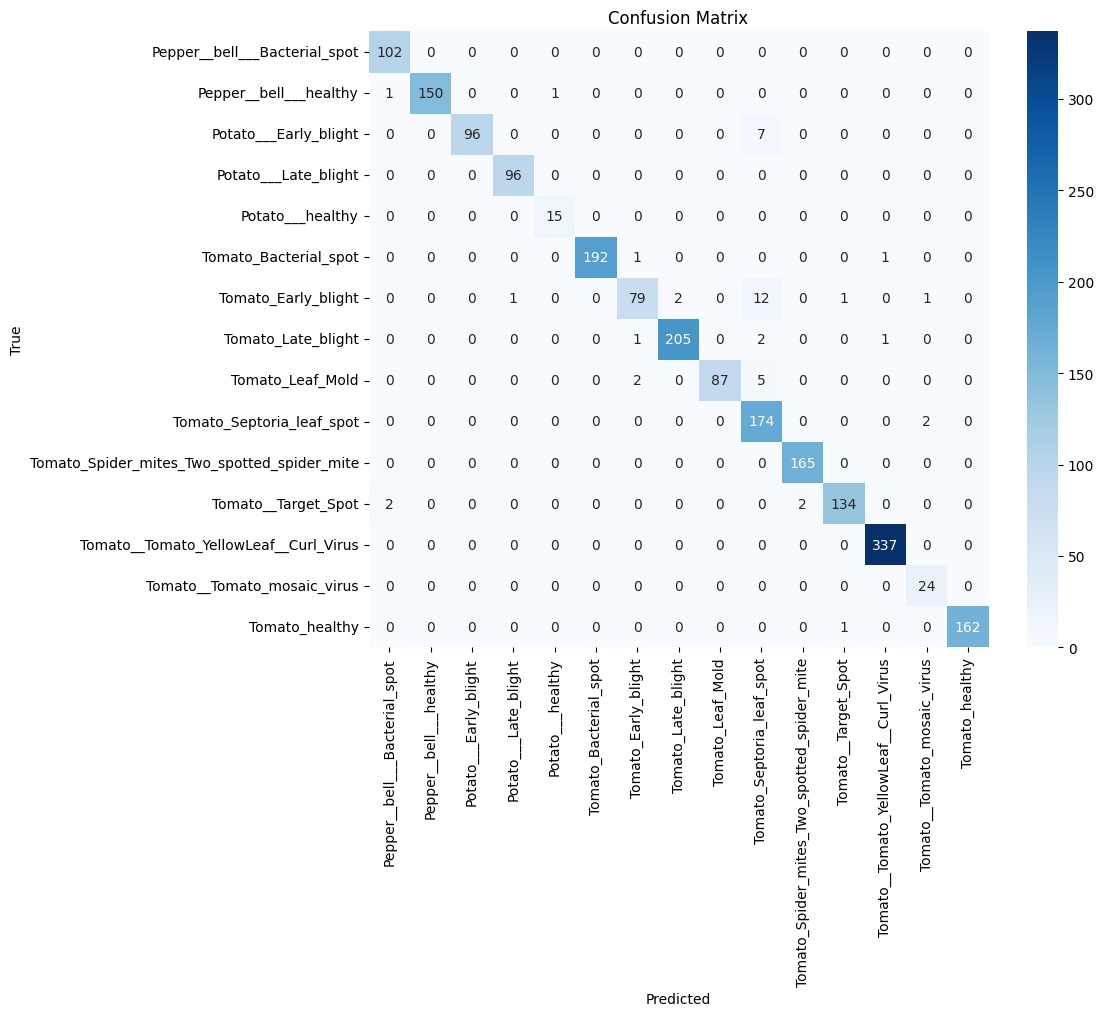

In [69]:
test_model(model, test_loader)
